# Assignment A3: OCR Comparison on img_2.jpg, img_3.jpg

Complete the tasks below in order. Use img_2.jpg and img_3.jpg and there matching ICDAR ground truth file.

In [43]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract
import re
import unicodedata

# Set this if Tesseract is not in PATH
pytesseract.pytesseract.tesseract_cmd = r"C:\\Program Files\\Tesseract-OCR\\tesseract.exe"

## Question 1.1: Set Paths for images

**Syntax:** `Path(r"...")`


In [44]:
image_path_2 = Path(r"D:\Handheld OCR Translator\Icdar2013\Challenge2_Test_Task12_Images\img_2.jpg")
gt_path_2 = Path(r"D:\Handheld OCR Translator\Icdar2013\Challenge2_Test_Task1_GT (1)\gt_img_2.txt")

image_path_3 = Path(r"D:\Handheld OCR Translator\Icdar2013\Challenge2_Test_Task12_Images\img_3.jpg")
gt_path_3 = Path(r"D:\Handheld OCR Translator\Icdar2013\Challenge2_Test_Task1_GT (1)\gt_img_3.txt")

print("Image 2:", image_path_2.resolve())
print("GT 2:", gt_path_2.resolve())
print("Image 3:", image_path_3.resolve())
print("GT 3:", gt_path_3.resolve())

Image 2: D:\Handheld OCR Translator\Icdar2013\Challenge2_Test_Task12_Images\img_2.jpg
GT 2: D:\Handheld OCR Translator\Icdar2013\Challenge2_Test_Task1_GT (1)\gt_img_2.txt
Image 3: D:\Handheld OCR Translator\Icdar2013\Challenge2_Test_Task12_Images\img_3.jpg
GT 3: D:\Handheld OCR Translator\Icdar2013\Challenge2_Test_Task1_GT (1)\gt_img_3.txt


## Question 1.2: Read and Display Image

**Syntax:** `cv2.imread(path)` and `cv2.cvtColor(image, cv2.COLOR_BGR2RGB)`

Text(0.5, 1.0, 'Target: img_2.jpg')

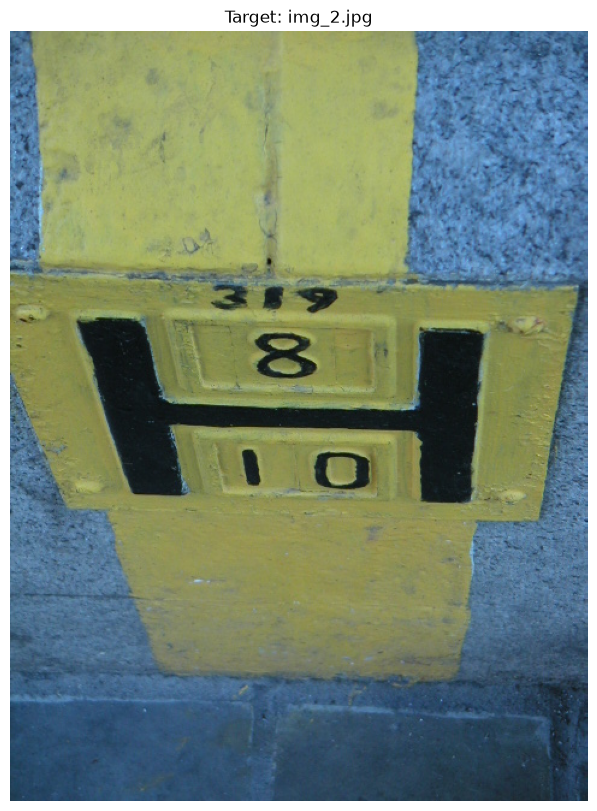

In [45]:
image_bgr_2 = cv2.imread(str(image_path_2))
image_rgb_2 = cv2.cvtColor(image_bgr_2, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(image_rgb_2)
plt.axis("off")
plt.title("Target: img_2.jpg")

Text(0.5, 1.0, 'Target: img_3.jpg')

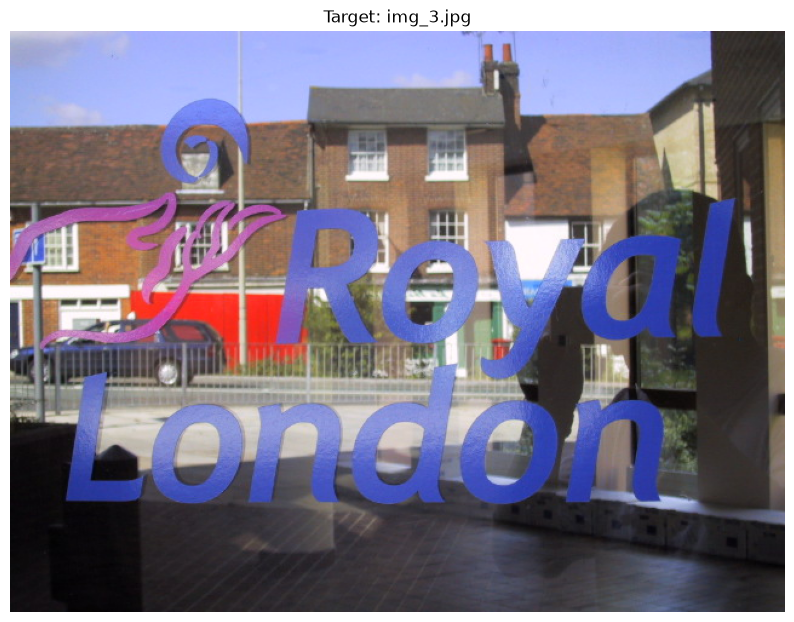

In [46]:
image_bgr_3 = cv2.imread(str(image_path_3))
image_rgb_3 = cv2.cvtColor(image_bgr_3, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(image_rgb_3)
plt.axis("off")
plt.title("Target: img_3.jpg")

## Question 1.3: Read Ground Truth and Build gt_text (Hint: modified the code to get gt_text for both img_2 and img_3)

**Syntax:** `Path.read_text(encoding, errors)` and `re.search(pattern, line)`

Keep the gt_words to gt_text conversion exactly as shown in the code cell below.

In [61]:
raw_gt_text = gt_path.read_text(encoding="utf-8", errors="ignore")
gt_words = []
for line in raw_gt_text.splitlines():
    # ICDAR format example: x1, y1, x2, y2, "word"
    match = re.search(r'"(.*?)"\s*$', line)
    if match:
        gt_words.append(match.group(1))

# Fallback to raw text if parsing finds no quoted transcription tokens.
gt_text = " ".join(gt_words).strip() if gt_words else raw_gt_text.strip()
print("Parsed GT (img_2):", gt_text)
gt_text

Parsed GT (img_2): 8 H 319 10


'8 H 319 10'

In [32]:
raw_gt_text_2 = gt_path_2.read_text(encoding="utf-8", errors="ignore")
gt_words_2 = []
for line in raw_gt_text_2.splitlines():
    # ICDAR format example: x1, y1, x2, y2, "word"
    match = re.search(r'"(.*?)"\s*$', line)
    if match:
        gt_words_2.append(match.group(1))

# Fallback to raw text if parsing finds no quoted transcription tokens.
gt_text_2 = " ".join(gt_words_2).strip() if gt_words_2 else raw_gt_text_2.strip()
print("Parsed GT:", gt_text_2)
gt_text_2

Parsed GT: 8 H 319 10


'8 H 319 10'

In [48]:
raw_gt_text_3 = gt_path_3.read_text(encoding="utf-8", errors="ignore")
gt_words_3 = []
for line in raw_gt_text_3.splitlines():
    # ICDAR format example: x1, y1, x2, y2, "word"
    match = re.search(r'"(.*?)"\s*$', line)
    if match:
        gt_words_3.append(match.group(1))

# Fallback to raw text if parsing finds no quoted transcription tokens.
gt_text_3 = " ".join(gt_words_3).strip() if gt_words_3 else raw_gt_text_3.strip()
print("Parsed GT:", gt_text_3)
gt_text_3

Parsed GT: Royal London


'Royal London'

## Question 2: Define CER and WER Functions (Given)

**Syntax:** `levenshtein_distance(seq1, seq2)` and `compute_cer_wer(gt_text, pred_text, ...)`

Keep the function syntax consistent with the OCR tutorial notebook.

In [49]:
def normalize_ocr_text(text, lowercase=True, remove_punctuation=False):
    """Normalize OCR output text for fair CER/WER comparison across engines."""
    if text is None:
        text = ""
    if not isinstance(text, str):
        text = str(text)

    text = unicodedata.normalize("NFKC", text)
    text = text.replace("\r\n", "\n").replace("\r", "\n").replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()

    if lowercase:
        text = text.lower()

    if remove_punctuation:
        text = re.sub(r"[^\w\s]", "", text)
        text = re.sub(r"\s+", " ", text).strip()

    return text


def levenshtein_distance(seq1, seq2):
    n, m = len(seq1), len(seq2)
    if n == 0:
        return m
    if m == 0:
        return n

    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if seq1[i - 1] == seq2[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )

    return dp[n][m]


def compute_cer_wer(
    gt_text,
    pred_text,
    lowercase=True,
    remove_punctuation=False,
    return_normalized_text=False,
    token_level="word",
):
    gt_norm = normalize_ocr_text(
        gt_text,
        lowercase=lowercase,
        remove_punctuation=remove_punctuation,
    )
    pred_norm = normalize_ocr_text(
        pred_text,
        lowercase=lowercase,
        remove_punctuation=remove_punctuation,
    )

    char_dist = levenshtein_distance(list(gt_norm), list(pred_norm))
    # Use max(ref_len, pred_len) denominator to keep CER in [0, 1].
    cer_den = max(1, len(gt_norm), len(pred_norm))
    cer = char_dist / cer_den

    if token_level == "char":
        gt_tokens = list(gt_norm)
        pred_tokens = list(pred_norm)
    else:
        gt_tokens = gt_norm.split()
        pred_tokens = pred_norm.split()

    token_dist = levenshtein_distance(gt_tokens, pred_tokens)
    # Use max(ref_tokens, pred_tokens) denominator to keep WER in [0, 1].
    wer_den = max(1, len(gt_tokens), len(pred_tokens))
    wer = token_dist / wer_den

    metrics = {
        "cer": cer,
        "wer": wer,
        "char_distance": char_dist,
        "token_distance": token_dist,
        "word_distance": token_dist,
        "gt_num_chars": len(gt_norm),
        "pred_num_chars": len(pred_norm),
        "gt_num_tokens": len(gt_tokens),
        "pred_num_tokens": len(pred_tokens),
        "gt_num_words": len(gt_tokens),
        "pred_num_words": len(pred_tokens),
        "cer_denominator": cer_den,
        "wer_denominator": wer_den,
        "normalization": {
            "lowercase": lowercase,
            "remove_punctuation": remove_punctuation,
            "token_level": token_level,
        },
    }

    if return_normalized_text:
        metrics["gt_normalized"] = gt_norm
        metrics["pred_normalized"] = pred_norm

    return metrics


def show_metrics(name, gt_text, pred_text, **kwargs):
    metrics = compute_cer_wer(gt_text, pred_text, **kwargs)
    print(f"{name} metrics:")
    print(f"  CER: {metrics['cer']:.4f} ({metrics['char_distance']} / {metrics['cer_denominator']})")
    print(f"  WER: {metrics['wer']:.4f} ({metrics['token_distance']} / {metrics['wer_denominator']})")
    print(f"  Normalization: {metrics['normalization']}")
    return metrics

## Question 3.1: Run PyTesseract OCR

**Syntax:** `pytesseract.image_to_string(image, lang="eng")`

In [50]:
detected_tesseract_2 = pytesseract.image_to_string(image_bgr_2, lang="eng")
detected_tesseract_3 = pytesseract.image_to_string(image_bgr_3, lang="eng")
detected_tesseract_2


'“ie arene\n\ni a aes\n'

In [51]:
detected_tesseract_3

''

In [56]:
metrics_tesseract_2 = show_metrics("PyTesseract (img_2)", gt_text_2, detected_tesseract_2)
metrics_tesseract_3 = show_metrics("PyTesseract (img_3)", gt_text_3, detected_tesseract_3)

PyTesseract (img_2) metrics:
  CER: 0.8235 (14 / 17)
  WER: 1.0000 (5 / 5)
  Normalization: {'lowercase': True, 'remove_punctuation': False, 'token_level': 'word'}
PyTesseract (img_3) metrics:
  CER: 1.0000 (12 / 12)
  WER: 1.0000 (2 / 2)
  Normalization: {'lowercase': True, 'remove_punctuation': False, 'token_level': 'word'}


## Question 3.2: Run EasyOCR

**Syntax:** `easyocr.Reader(["en"], gpu=False).readtext(image_path, detail=1, paragraph=False)`

In [52]:
import easyocr
reader = easyocr.Reader(["en"], gpu=False)
easyocr_result_2 = reader.readtext(str(image_path_2), detail=1, paragraph=False)
easyocr_text_2 = " ".join([item[1] for item in easyocr_result_2]).strip()
easyocr_text_2

Using CPU. Note: This module is much faster with a GPU.
d:\Handheld OCR Translator\handheld-ocr-translator\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


'30>'

In [53]:
easyocr_result_3 = reader.readtext(str(image_path_3), detail=1, paragraph=False)
easyocr_text_3 = " ".join([item[1] for item in easyocr_result_3]).strip()
easyocr_text_3

d:\Handheld OCR Translator\handheld-ocr-translator\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


'5a374 Loner'

In [57]:
metrics_easyocr_2 = show_metrics("EasyOCR", gt_text_2, easyocr_text_2)

EasyOCR metrics:
  CER: 0.9000 (9 / 10)
  WER: 1.0000 (4 / 4)
  Normalization: {'lowercase': True, 'remove_punctuation': False, 'token_level': 'word'}


In [58]:
metrics_easyocr_3 = show_metrics("EasyOCR", gt_text_3, easyocr_text_3)

EasyOCR metrics:
  CER: 0.6667 (8 / 12)
  WER: 1.0000 (2 / 2)
  Normalization: {'lowercase': True, 'remove_punctuation': False, 'token_level': 'word'}


## Question 3.3: Run PaddleOCR

**Syntax:** `PaddleOCR(...).predict(image_path)` and `page.get("rec_texts", [])`

In [54]:
from paddleocr import PaddleOCR
paddle_reader = PaddleOCR(use_textline_orientation=True, lang="en")
paddle_result_2 = paddle_reader.predict(str(image_path_2))

texts_2 = []
for page in paddle_result_2:
    texts_2.extend(page.get("rec_texts", []))

paddle_text_2 = " ".join(texts_2).strip()
paddle_text_2

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\14zj2\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.


Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\14zj2\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\14zj2\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\14zj2\.paddlex\official_models\PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\14zj2\.paddlex\official_models\PP-OCRv6_medium_rec`.


'319 8 0'

In [55]:
paddle_result_3 = paddle_reader.predict(str(image_path_3))

texts_3 = []
for page in paddle_result_3:
    texts_3.extend(page.get("rec_texts", []))

paddle_text_3 = " ".join(texts_3).strip()
paddle_text_3

'Royal London'

In [59]:
metrics_paddleocr_2 = show_metrics("PaddleOCR", gt_text_2, paddle_text_2)

PaddleOCR metrics:
  CER: 0.6000 (6 / 10)
  WER: 1.0000 (4 / 4)
  Normalization: {'lowercase': True, 'remove_punctuation': False, 'token_level': 'word'}


In [60]:
metrics_paddleocr_3 = show_metrics("PaddleOCR", gt_text_3, paddle_text_3)

PaddleOCR metrics:
  CER: 0.0000 (0 / 12)
  WER: 0.0000 (0 / 2)
  Normalization: {'lowercase': True, 'remove_punctuation': False, 'token_level': 'word'}


## Question 4: Save Outputs (All Methods)

**Syntax:** `Path.mkdir(exist_ok=True)` and `Path.write_text(content, encoding="utf-8")`

In [ ]:
out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)

text_outputs = {
    "tesseract": detected_tesseract_2.strip(),
    "easyocr": easyocr_text_2.strip(),
    "paddleocr": paddle_text_2.strip(),
}

for method_name, text_value in text_outputs.items():
    out_path = out_dir / f"img_2_{method_name}_ocr.txt"
    out_path.write_text(text_value, encoding="utf-8")
    print(f"Saved {method_name} OCR: {out_path.resolve()}")

Saved tesseract OCR: D:\Handheld OCR Translator\handheld-ocr-translator\assignment\A3\outputs\img_2_tesseract_ocr.txt
Saved easyocr OCR: D:\Handheld OCR Translator\handheld-ocr-translator\assignment\A3\outputs\img_2_easyocr_ocr.txt
Saved paddleocr OCR: D:\Handheld OCR Translator\handheld-ocr-translator\assignment\A3\outputs\img_2_paddleocr_ocr.txt
